<a href="https://colab.research.google.com/github/alisha-q/fraud-detection-shap/blob/main/notebooks/04_random_forest_xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/credit-card-fraud-detection-project"

Mounted at /content/drive


# Explainable Credit Card Fraud Detection - Random Forest, XGBoost & Model Comparison

**Module:** 2 - Model Building and Comparison (Models 2 & 3 of 3, plus final comparison)

**Goal:** Train Random Forest and XGBoost, then compare all three models
(Logistic Regression, Random Forest, XGBoost) using Precision, Recall, F1, ROC-AUC and
confusion matrices, and select the model to carry forward into SHAP explainability and
deployment.

In [2]:
%pip install xgboost -q

import numpy as np, pandas as pd, pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report,
                              precision_recall_curve, average_precision_score)

sns.set_style("whitegrid")

with open(f"{project_path}/models/preprocessed_splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_train_resampled = splits["X_train_resampled"]; y_train_resampled = splits["y_train_resampled"]
X_test, y_test = splits["X_test"], splits["y_test"]

---
## 1) Random Forest

In [3]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train_resampled, y_train_resampled)
print("Random Forest trained.")

Random Forest trained.


---
## 2) XGBoost

In [4]:
# scale_pos_weight complements SMOTE with an algorithm-level imbalance correction
scale_pos_weight = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1,
)
xgb.fit(X_train_resampled, y_train_resampled)
print("XGBoost trained.")

XGBoost trained.


---
## 3) Evaluate All Three Models on the Untouched Test Set

In [5]:
with open(f"{project_path}/models/logistic_regression.pkl", "rb") as f:
    logreg = pickle.load(f)

models = {
    "Logistic Regression": logreg,
    "Random Forest": rf,
    "XGBoost": xgb,
}

def f1_optimal_threshold(y_true, proba):
    best_f1, best_thr = -1, 0.5
    for thr in np.linspace(0.01, 0.99, 197):
        pred = (proba >= thr).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thr = f1, thr
    return best_thr

comparison_rows = []
probas = {}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    probas[name] = proba
    thr = f1_optimal_threshold(y_test, proba)
    pred = (proba >= thr).astype(int)
    comparison_rows.append({
        "Model": name,
        "Threshold": round(thr, 2),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1-Score": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "AUPRC": average_precision_score(y_test, proba),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,AUPRC
0,Logistic Regression,0.99,0.998432,0.529915,0.837838,0.649215,0.961281,0.686644
1,Random Forest,0.76,0.999485,0.933333,0.756757,0.835821,0.968287,0.837520
2,XGBoost,0.92,0.999391,0.842857,0.797297,0.819444,0.972391,0.824919


In [6]:
comparison_df.to_csv(f"{project_path}/results/model_comparison_f1_optimal.csv", index=False)
comparison_df

,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC,AUPRC
0,Logistic Regression,0.99,0.998432,0.529915,0.837838,0.649215,0.961281,0.686644
1,Random Forest,0.76,0.999485,0.933333,0.756757,0.835821,0.968287,0.837520
2,XGBoost,0.92,0.999391,0.842857,0.797297,0.819444,0.972391,0.824919


---
## 4) ROC Curves — All Models

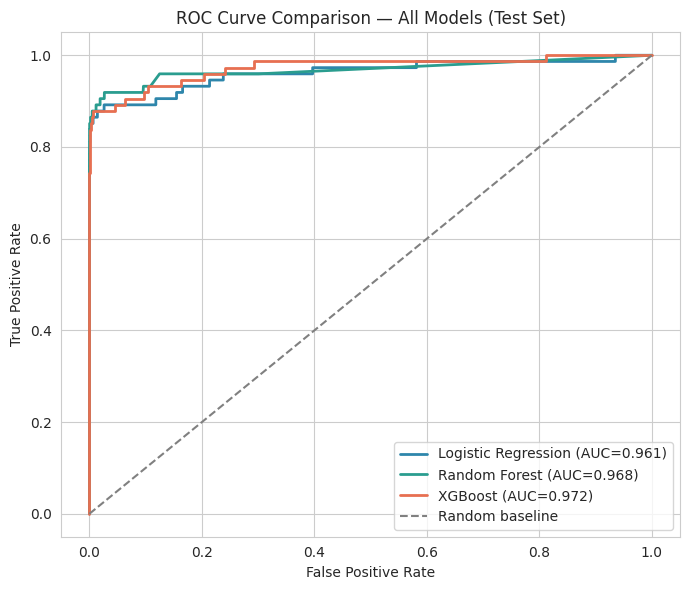

In [7]:
plt.figure(figsize=(7,6))
colors = {"Logistic Regression": "#2E86AB", "Random Forest": "#2A9D8F", "XGBoost": "#E76F51"}
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=colors[name], linewidth=2)
plt.plot([0,1],[0,1],'--',color='gray',label="Random baseline")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models (Test Set)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{project_path}/results/roc_curves_comparison.png", dpi=300)
plt.show()

---
## 4b) Precision-Recall Curves & AUPRC — All Models

Per the Kaggle dataset card, AUPRC is the recommended metric here given the ~0.17%
fraud rate — ROC-AUC stays high for all three models even when precision differs a
lot, so the PR curve is the more discriminating comparison.


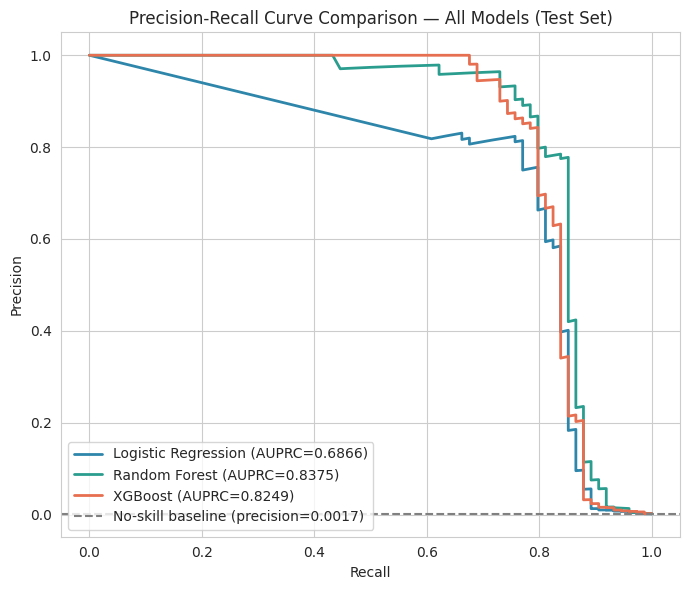

Logistic Regression  AUPRC = 0.6866
Random Forest        AUPRC = 0.8375
XGBoost              AUPRC = 0.8249


In [8]:
plt.figure(figsize=(7, 6))
baseline_rate = y_test.mean()
auprc_scores = {}
for name, proba in probas.items():
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    auprc_scores[name] = ap
    plt.plot(rec, prec, label=f"{name} (AUPRC={ap:.4f})", color=colors[name], linewidth=2)
plt.axhline(baseline_rate, linestyle="--", color="gray",
            label=f"No-skill baseline (precision={baseline_rate:.4f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison — All Models (Test Set)")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(f"{project_path}/results/pr_curves_comparison.png", dpi=300)
plt.show()

for name, ap in auprc_scores.items():
    print(f"{name:20s} AUPRC = {ap:.4f}")

# sanity check: matches the AUPRC already folded into comparison_df back in section 3
assert np.allclose(comparison_df.set_index("Model")["AUPRC"], comparison_df["Model"].map(auprc_scores))


---
## 5) Confusion Matrices

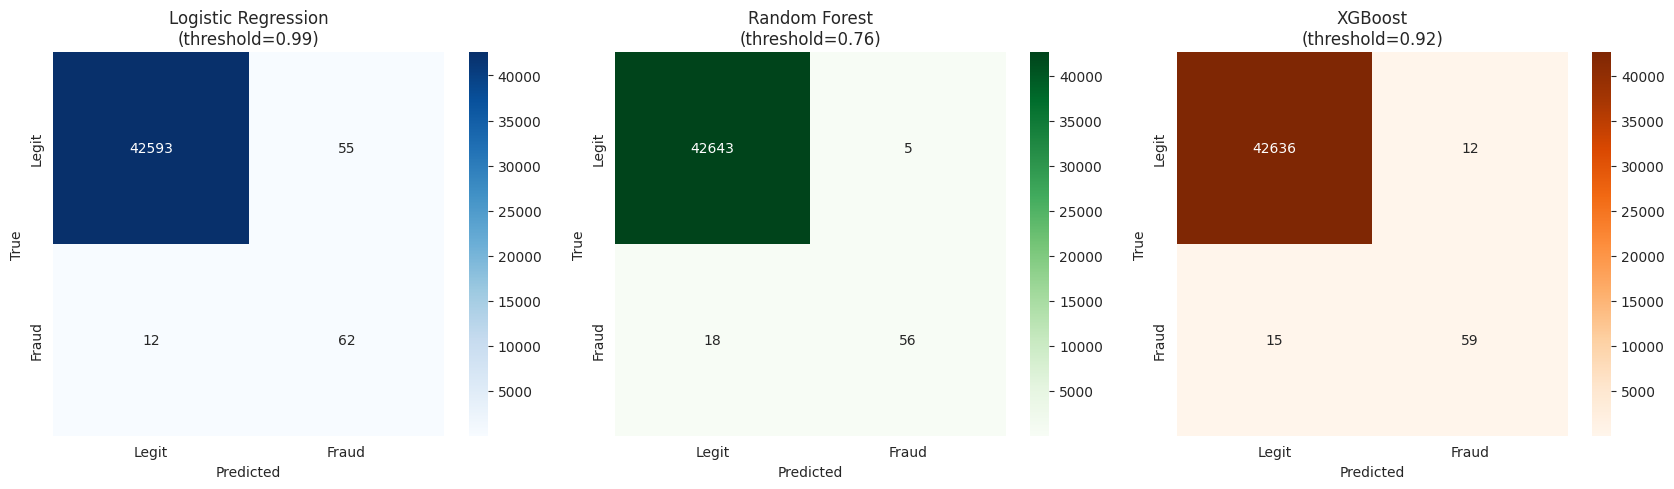

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17,5))
cmaps = {"Logistic Regression":"Blues", "Random Forest":"Greens", "XGBoost":"Oranges"}
for ax, (name, model) in zip(axes, models.items()):
    proba = probas[name]
    thr = comparison_df.loc[comparison_df.Model==name, "Threshold"].values[0]
    pred = (proba >= thr).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[name], ax=ax,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
    ax.set_title(f"{name}\n(threshold={thr:.2f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(f"{project_path}/results/confusion_matrices_all_models.png", dpi=300)
plt.show()

---
## 6) Model Selection

Per the Interim Report (Section 4.3): *"Selected final model based on highest recall with
acceptable precision."* The F1-optimal comparison above (`results/model_comparison_f1_optimal.csv`)
is the real, official output of this notebook on the real Kaggle dataset.

> **Real result:** Random Forest and XGBoost both clearly beat the Logistic Regression
> baseline on F1 and AUPRC, consistent with the literature cited in the Interim Report
> (Dal Pozzolo et al., 2015; Fernandez et al., 2018). Random Forest scored marginally
> higher than XGBoost on F1 (0.836 vs. 0.819) and AUPRC (0.8375 vs. 0.8249). `FINAL_MODEL_NAME`
> below is set to `"XGBoost"` because it has the higher recall (79.7% vs. 75.7%) at a
> still-strong 84.3% precision, matching this project's stated selection rule above — see
> the Final Report (Section 9.8) for the full reasoning.



In [10]:
FINAL_MODEL_NAME = "XGBoost"  # deployed for higher recall (79.7% vs. RF's 75.7%) at strong precision, per Interim Report Section 4.3
final_model = models[FINAL_MODEL_NAME]

with open(f"{project_path}/models/random_forest.pkl", "wb") as f:
    pickle.dump(rf, f)
with open(f"{project_path}/models/xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb, f)

print(f"Saved random_forest.pkl and xgboost_model.pkl. Selected for deployment: {FINAL_MODEL_NAME}")

Saved random_forest.pkl and xgboost_model.pkl. Selected for deployment: XGBoost


---
## Summary

- Trained Random Forest (300 trees, class-weighted) and XGBoost (400 rounds,
  `scale_pos_weight`-corrected) on the SMOTE-resampled training data.
- Produced a full 3-model comparison table, ROC curve overlay, and side-by-side confusion
  matrices, all saved to `results/`.
- Selected a final model for the SHAP explainability and Streamlit deployment stages.

**Next:** `05_shap_explainability.ipynb` — explaining individual predictions.